# Kang & Kim (2022) — nhân vector SDG và vẽ bảng

Notebook này **không load model**. Vector đã được `run_pipeline.py` lưu trong `data/embeddings/`.

Công thức paper: với mỗi câu báo cáo $r$ và mỗi mục tiêu $g$, điểm là **trung bình cosine** tới mọi câu SDG của mục tiêu đó. Cosine của hai vector đã L2-normalize chính là **tích vô hướng** $r^\top s$.

$$\mathrm{sim}(r, g) = \frac{1}{|S_g|} \sum_{s \in S_g} \hat r \cdot \hat s$$

Sau đó kéo min–max toàn cục về 0–100, gộp theo công ty–năm, rồi theo 6 nhóm SDG.

Chạy trước (một lần, có model):

```
python load_models.py --only vi_sbert vi_sentiment
python process_data.py
python run_pipeline.py --lang vi
```

## 0. Đường dẫn

In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "config.py").exists():
    ROOT = Path(r"C:\Code\paper_sdg")
sys.path.insert(0, str(ROOT))

from config import (
    CATEGORY_MAP,
    CATEGORY_ORDER,
    EMBED_DIR,
    FIGURE_DIR,
    GOAL_COLS,
    GOAL_TITLE_VI,
    RESULT_DIR,
)
from src.aggregate import category_means, company_year_means, minmax_scale_goals, sentiment_ratio
from src.encode import cosine_from_normalized, mean_similarity_by_goal

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
sns.set_style("whitegrid")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print("ROOT", ROOT)
print("embeddings", list(EMBED_DIR.glob("*")))

C:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT c:\Code\paper_sdg
embeddings [WindowsPath('C:/Code/paper_sdg/data/embeddings/.gitkeep'), WindowsPath('C:/Code/paper_sdg/data/embeddings/meta_vi.json'), WindowsPath('C:/Code/paper_sdg/data/embeddings/report_index_vi.pkl'), WindowsPath('C:/Code/paper_sdg/data/embeddings/report_vi.npy'), WindowsPath('C:/Code/paper_sdg/data/embeddings/sdg_index_vi.pkl'), WindowsPath('C:/Code/paper_sdg/data/embeddings/sdg_vi.npy'), WindowsPath('C:/Code/paper_sdg/data/embeddings/sim_vi.npy')]


## 1. Load vector đã lưu (không model)

Mỗi ngôn ngữ một cặp ma trận:
- `report_{lang}.npy` — `(n_câu_báo_cáo, dim)` đã L2-normalize
- `sdg_{lang}.npy` — `(n_câu_SDG, dim)` đã L2-normalize

Báo cáo hiện có chủ yếu tiếng Việt → ưu tiên `vi`. Tiếng Anh chạy khi có PDF EN.

In [2]:
def available_langs():
    out = []
    for lang in ("vi", "en"):
        if (EMBED_DIR / f"report_{lang}.npy").exists() and (EMBED_DIR / f"sdg_{lang}.npy").exists():
            out.append(lang)
    return out

LANGS = available_langs()
print("langs with embeddings:", LANGS)
if not LANGS:
    raise FileNotFoundError(
        "Chưa có file embedding. Chạy: python run_pipeline.py --lang vi --encode-only"
    )

langs with embeddings: ['vi']


## 2. Nhân vector = cosine similarity

`sim = report @ sdg.T` cho ma trận `(n_report, n_sdg)`.  
Cột được gộp theo `goalnum` bằng trung bình — đúng bước trong `02_sentence_similarity.ipynb` của paper.

In [3]:
parts = []
for lang in LANGS:
    report_emb = np.load(EMBED_DIR / f"report_{lang}.npy")
    sdg_emb = np.load(EMBED_DIR / f"sdg_{lang}.npy")
    report_idx = pd.read_pickle(EMBED_DIR / f"report_index_{lang}.pkl")
    sdg_idx = pd.read_pickle(EMBED_DIR / f"sdg_index_{lang}.pkl")

    print(f"[{lang}] report {report_emb.shape}  sdg {sdg_emb.shape}  (nhân cosine)")
    sim = cosine_from_normalized(report_emb, sdg_emb)
    print(f"[{lang}] sim {sim.shape}  min={sim.min():.3f}  max={sim.max():.3f}  mean={sim.mean():.3f}")

    goals = mean_similarity_by_goal(sim, sdg_idx["goalnum"], GOAL_COLS)
    part = pd.concat([report_idx.reset_index(drop=True), goals.reset_index(drop=True)], axis=1)
    parts.append(part)

    display(sdg_idx["goalnum"].value_counts().sort_index().to_frame("n_sdg_sentences").T)

df = pd.concat(parts, ignore_index=True)
print("rows", len(df), "files", df["fname"].nunique())
df.head(3)

[vi] report (17047, 768)  sdg (391, 768)  (nhân cosine)
[vi] sim (17047, 391)  min=-0.219  max=0.913  mean=0.232


goalnum,goal01,goal02,goal03,goal04,goal05,goal06,goal07,goal08,goal09,goal10,goal11,goal12,goal13,goal14,goal15,goal16,goal17
n_sdg_sentences,24,21,25,22,23,21,19,22,21,24,22,25,21,24,27,26,24


rows 17047 files 29


,doc_id,fname,company,year,doc_lang,sent_lang,sent_idx,sentence,goal01,goal02,goal03,goal04,goal05,goal06,goal07,goal08,goal09,goal10,goal11,goal12,goal13,goal14,goal15,goal16,goal17
0,0,PAN_SR_2019.pdf,PAN,2019,vi,vi,0,2 | T r g Công ty cổ phần Tập đoàn PAN Với khá...,0.385269,0.451202,0.288842,0.348707,0.280563,0.275211,0.304100,0.346975,0.342043,0.308209,0.326961,0.320437,0.225906,0.267424,0.346642,0.298605,0.394813
1,0,PAN_SR_2019.pdf,PAN,2019,vi,vi,1,"Chúng tôi hiểu rằng nông nghiệp, bao gồm cả th...",0.322611,0.352650,0.208942,0.285295,0.209811,0.266286,0.207738,0.255405,0.272582,0.247507,0.242400,0.261440,0.206513,0.268510,0.268738,0.220232,0.266438
2,0,PAN_SR_2019.pdf,PAN,2019,vi,vi,2,Chúng tôi không ngừng nỗ lực nâng cao chất lượ...,0.230536,0.294942,0.220990,0.267305,0.232512,0.200737,0.238197,0.231640,0.249650,0.189901,0.199941,0.254508,0.156224,0.192071,0.221247,0.195125,0.246313


## 2b. Thống kê số câu và trung bình số câu trên trang mỗi báo cáo

Bảng tổng hợp cho 29 báo cáo: tổng số câu trích xuất, số trang PDF và mật độ câu/trang.

In [4]:
# Thống kê số câu và trung bình số câu trên trang cho từng báo cáo
import fitz
from config import PDF_DIR

pdf_map = {p.name: p for p in PDF_DIR.glob('*/*.pdf')} if PDF_DIR.exists() else {}

stats = []
for (comp, yr, fn), grp in df.groupby(['company', 'year', 'fname'], sort=True):
    n_sents = len(grp)
    pdf_p = pdf_map.get(fn)
    n_pages = None
    if pdf_p and pdf_p.exists():
        try:
            doc = fitz.open(pdf_p)
            n_pages = len(doc)
            doc.close()
        except Exception:
            pass
    spp = round(n_sents / n_pages, 2) if n_pages else np.nan
    stats.append({
        'Công ty': comp,
        'Năm': yr,
        'Tên file': fn,
        'Số câu': n_sents,
        'Số trang': n_pages,
        'Số câu / trang': spp,
    })

df_doc_stats = pd.DataFrame(stats)

# Lưu bảng thống kê
out_stats_csv = RESULT_DIR / 'table_report_sentence_stats.csv'
df_doc_stats.to_csv(out_stats_csv, index=False, encoding='utf-8-sig')

tot_sents = df_doc_stats['Số câu'].sum()
avg_spp = df_doc_stats['Số câu / trang'].mean()
print(f'Tổng số báo cáo: {len(df_doc_stats)} | Tổng số câu: {tot_sents:,} | Trung bình: {avg_spp:.2f} câu/trang')
print(f'Đã lưu bảng thống kê vào: {out_stats_csv.name}')
display(df_doc_stats)


Tổng số báo cáo: 29 | Tổng số câu: 17,047 | Trung bình: 7.19 câu/trang
Đã lưu bảng thống kê vào: table_report_sentence_stats.csv


,Công ty,Năm,Tên file,Số câu,Số trang,Số câu / trang
0,PAN,2019,PAN_SR_2019.pdf,618,112,5.52
1,PAN,2020,PAN_SR_2020.pdf,752,83,9.06
2,PAN,2021,PAN_SR_2021.pdf,834,76,10.97
3,PAN,2022,PAN_SR_2022.pdf,812,67,12.12
4,PAN,2023,PAN_SR_2023.pdf,411,61,6.74
5,PAN,2024,PAN_SR_2024.pdf,788,87,9.06
6,PAN,2025,PAN_SR_2025.pdf,730,89,8.20
7,PLX,2018,PLX_SR_2018.pdf,413,59,7.00
8,PLX,2019,PLX_SR_2019.pdf,747,89,8.39
9,PLX,2020,PLX_SR_2020.pdf,842,85,9.91


## 3. Kéo điểm similarity về 0–100

Paper: $(x - \min) \times 100 / (\max - \min)$ trên toàn bộ 17 cột goal.

In [5]:
df_s = minmax_scale_goals(df)
print("raw min", df_s.attrs.get("sim_min"), "raw max", df_s.attrs.get("sim_max"))
df_s[GOAL_COLS].describe().round(2)

raw min -0.023498469963669777 raw max 0.524976909160614


,goal01,goal02,goal03,goal04,goal05,goal06,goal07,goal08,goal09,goal10,goal11,goal12,goal13,goal14,goal15,goal16,goal17
count,17047.00,17047.00,17047.00,17047.00,17047.00,17047.00,17047.00,17047.00,17047.00,17047.00,17047.00,17047.00,17047.00,17047.00,17047.00,17047.00,17047.00
mean,48.35,48.28,42.42,46.76,38.70,44.56,47.94,48.18,50.11,44.70,44.12,49.71,44.28,45.97,49.01,45.56,53.74
std,12.48,12.46,10.69,12.95,11.51,12.32,12.40,13.72,14.11,10.76,11.43,12.11,11.88,11.16,12.70,11.73,15.25
min,6.13,7.64,8.63,7.34,0.00,0.89,7.08,5.26,4.06,9.19,6.18,6.88,1.64,7.79,5.77,5.60,7.82
25%,39.45,39.56,34.99,37.36,30.60,36.43,39.00,38.23,40.11,37.01,36.28,41.30,36.13,38.18,40.21,37.34,42.86
50%,48.85,48.76,42.83,46.84,38.87,43.94,48.36,48.37,50.25,45.21,44.62,50.24,44.36,46.33,49.41,46.21,53.78
75%,57.55,57.08,50.29,55.66,46.82,51.73,56.86,58.00,60.27,52.72,52.32,58.51,52.52,53.96,58.06,54.26,64.73
max,85.41,90.48,76.30,92.11,86.98,96.79,84.94,91.60,92.85,74.65,77.97,84.69,87.19,84.24,94.37,77.66,100.00


## 4. Bảng trung bình theo công ty × năm (17 SDG)

In [6]:
df_comp = company_year_means(df_s)
show = df_comp[GOAL_COLS].round(2)
show.columns = [f"{c}\n{GOAL_TITLE_VI[c]}" for c in GOAL_COLS]
display(show)
show.to_csv(RESULT_DIR / "table_company_year_17sdg.csv", encoding="utf-8-sig")
print("saved", RESULT_DIR / "table_company_year_17sdg.csv")

goal01\nChấm dứt nghèo  goal02\nKhông còn nạn đói  goal03\nSức khỏe và phúc lợi  goal04\nGiáo dục chất lượng  \
company year                                                                                                                 
PAN     2019               48.330002                  50.540001                     42.000000                    46.130001   
        2020               45.560001                  47.759998                     40.139999                    44.139999   
        2021               48.799999                  50.770000                     42.470001                    46.160000   
        2022               49.310001                  50.950001                     42.619999                    46.529999   
        2023               46.220001                  48.340000                     40.220001                    45.830002   
        2024               47.400002                  51.020000                     41.349998                    46.820000   
        2025               51.139999                  54.279999                     44.470001                    51.060001   
PLX     2018               48.919998                  46.430000                     41.330002                    44.189999   
        2019               48.180000                  45.759998                     41.200001                    44.320000   
        2020               48.669998                  46.230000                     42.430000                    45.389999   
        2021               49.990002                  47.880001                     43.279999                    45.709999   
        2022               47.299999                  45.709999                     40.970001                    44.549999   
        2023               46.770000                  45.040001                     39.930000                    43.619999   
        2024               46.150002                  44.540001                     41.590000                    44.070000   
        2025               48.090000                  46.419998                     42.029999                    45.630001   
PNJ     2019               49.400002                  46.930000                     44.290001                    49.060001   
        2020               51.490002                  48.590000                     45.419998                    50.320000   
        2021               49.840000                  46.889999                     44.099998                    48.150002   
        2022               52.700001                  48.570000                     48.470001                    50.560001   
        2023               46.889999                  44.590000                     42.150002                    46.930000   
        2024               49.939999                  47.529999                     44.490002                    49.650002   
        2025               51.080002                  49.130001                     45.619999                    51.669998   
VNM     2019               44.740002                  44.900002                     39.220001                    43.060001   
        2020               46.730000                  45.889999                     40.360001                    45.740002   
        2021               47.580002                  47.110001                     41.910000                    46.110001   
        2022               44.270000                  45.910000                     39.279999                    43.759998   
        2023               47.080002                  48.900002                     41.980000                    46.980000   
        2024               46.369999                  48.389999                     41.279999                    45.880001   
        2025               51.410000                  53.279999                     45.480000                    50.020000   

              goal05\nBình đẳng giới  goal06\nNước sạch và vệ sinh  goal07\nNăng lượng sạch với giá phải ch

saved C:\Code\paper_sdg\data\results\table_company_year_17sdg.csv


## 5. Gộp 17 SDG thành 6 nhóm (paper Table grouping)

| Nhóm | SDG |
|---|---|
| Life | 1, 2, 3 |
| Economic | 8, 9 |
| Equity | 4, 5, 10 |
| Social | 11, 16, 17 |
| Resources | 6, 7, 12, 14 |
| Environments | 13, 15 |

In [7]:
df_cat = category_means(df_comp)
display(df_cat.round(2))
df_cat.round(2).to_csv(RESULT_DIR / "table_company_year_6cat.csv", encoding="utf-8-sig")

category           Life   Economic     Equity     Social  Resources  Environments
company year                                                                     
PAN     2019  46.950001  48.180000  42.610001  46.240002  45.980000     45.240002
        2020  44.490002  45.980000  40.209999  44.139999  43.720001     42.959999
        2021  47.349998  49.020000  42.939999  47.040001  45.660000     45.509998
        2022  47.630001  49.830002  43.799999  47.799999  46.820000     46.680000
        2023  44.930000  46.830002  42.160000  45.099998  43.480000     42.959999
        2024  46.590000  48.119999  42.340000  46.470001  46.009998     46.099998
        2025  49.970001  52.990002  45.799999  50.500000  49.700001     49.680000
PLX     2018  45.560001  47.740002  42.169998  46.500000  45.599998     45.270000
        2019  45.049999  47.419998  41.950001  45.990002  45.779999     44.959999
        2020  45.779999  48.389999  42.509998  47.080002  46.540001     46.080002
        2021  47.049999  50.459999  41.740002  48.869999  47.549999     47.900002
        2022  44.660000  47.799999  42.049999  46.549999  46.279999     45.889999
        2023  43.919998  46.849998  41.259998  46.450001  45.290001     45.639999
        2024  44.090000  50.200001  39.919998  48.820000  48.220001     49.910000
        2025  45.509998  48.480000  42.290001  47.709999  46.880001     47.150002
PNJ     2019  46.869999  52.279999  45.900002  50.639999  49.840000     48.380001
        2020  48.500000  53.900002  46.919998  51.750000  50.770000     49.500000
        2021  46.939999  50.959999  44.290001  49.459999  50.110001     48.400002
        2022  49.910000  54.840000  47.380001  52.990002  50.209999     51.169998
        2023  44.540001  48.580002  43.230000  47.330002  47.230000     45.360001
        2024  47.320000  52.070000  45.980000  50.689999  50.509998     48.939999
        2025  48.610001  53.259998  47.400002  51.750000  50.610001     49.540001
VNM     2019  42.950001  44.610001  40.799999  44.240002  43.490002     42.599998
        2020  44.330002  47.419998  41.709999  47.509998  44.900002     44.750000
        2021  45.529999  47.880001  42.389999  47.680000  45.130001     44.750000
        2022  43.150002  44.970001  40.580002  44.590000  44.040001     44.450001
        2023  45.990002  48.310001  43.590000  47.459999  47.160000     47.180000
        2024  45.349998  47.430000  42.830002  46.570000  46.310001     46.299999
        2025  50.060001  52.279999  46.480000  51.160000  51.130001     51.950001

## 6. Biểu đồ xu hướng 6 nhóm theo năm (từng công ty)

companies: ['PAN', 'PLX', 'PNJ', 'VNM']


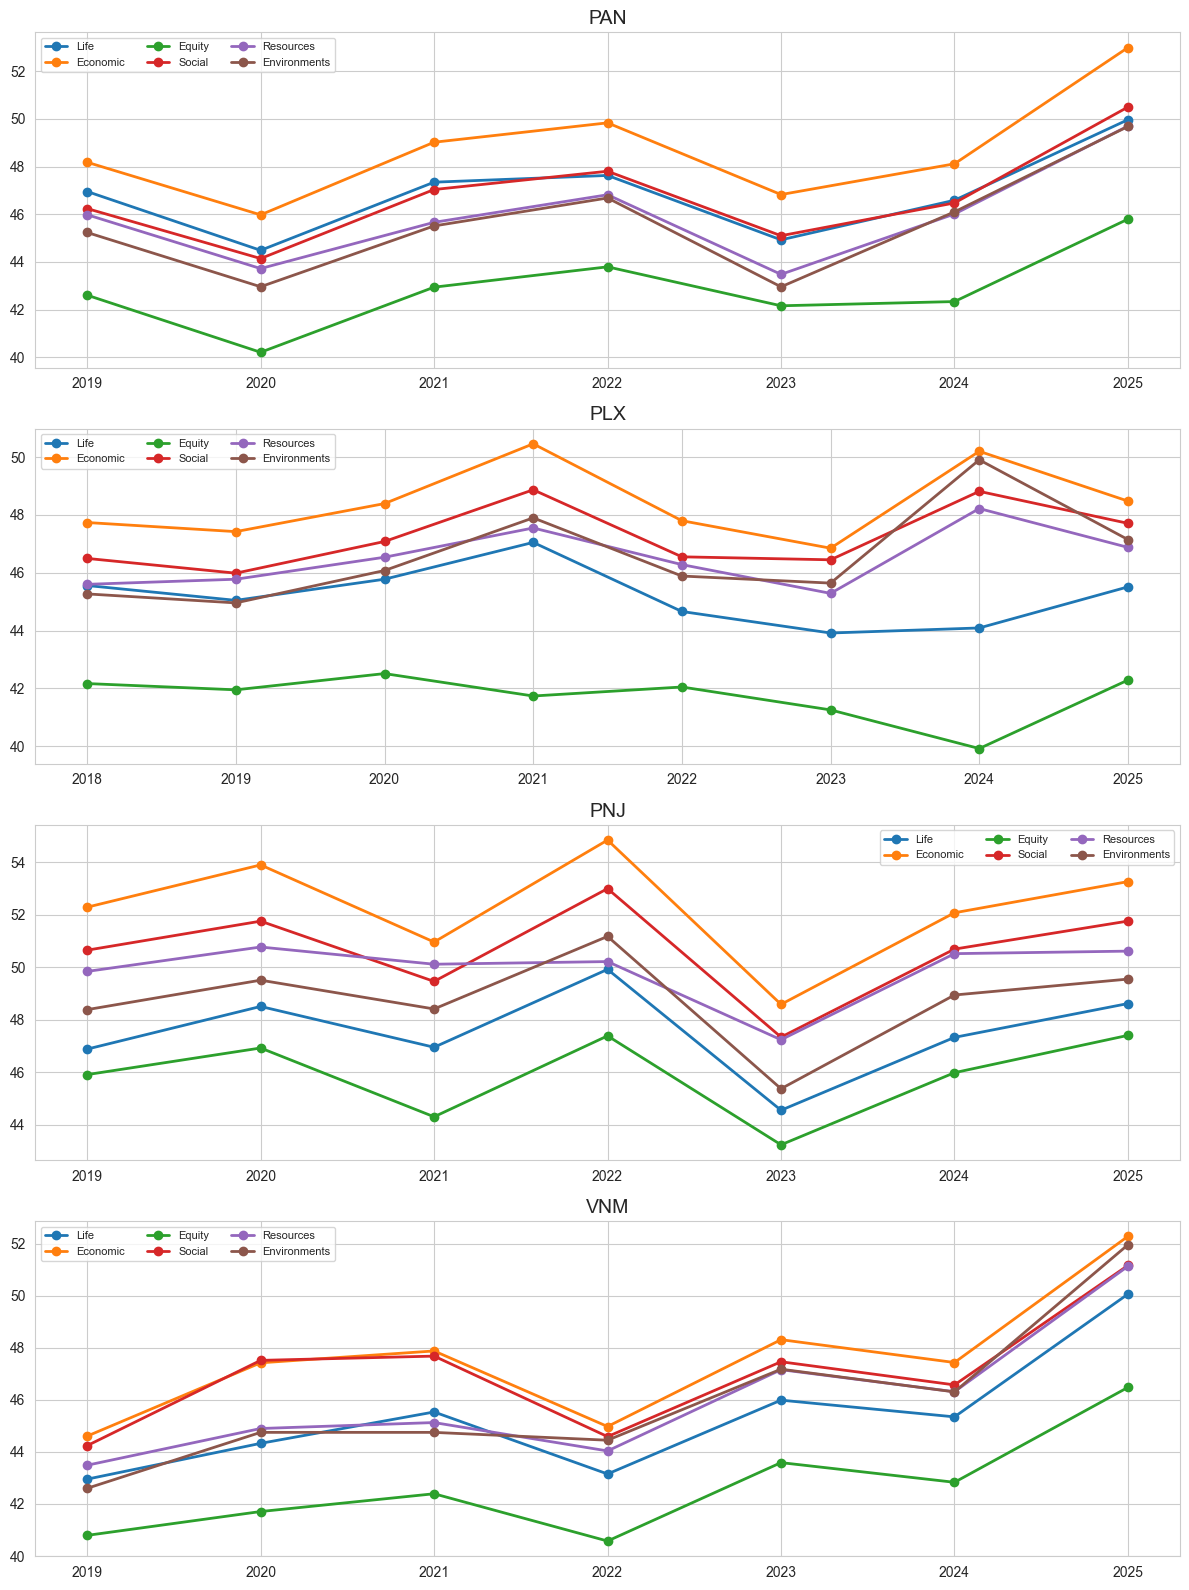

In [8]:
companies = sorted(df_s["company"].dropna().unique())
print("companies:", companies)

n = len(companies)
fig, axes = plt.subplots(n, 1, figsize=(12, 4 * max(n, 1)), squeeze=False)
for ax, company in zip(axes.ravel(), companies):
    sub = df_cat.loc[company].sort_index()
    for col in CATEGORY_ORDER:
        if col in sub.columns:
            ax.plot(sub.index.astype(str), sub[col], marker="o", linewidth=2, label=col)
    ax.set_title(company, fontsize=14)
    ax.grid(True)
    ax.legend(loc="best", fontsize=8, ncol=3)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "trends_6categories.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Phân phối điểm similarity (sau scale 0–100)

mean 46.61 std 12.83


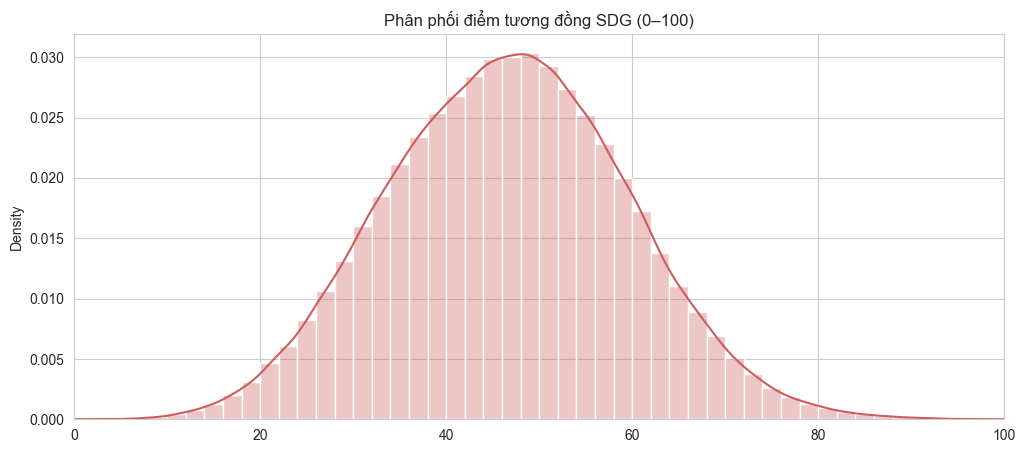

In [9]:
stacked = pd.concat([df_s[c] for c in GOAL_COLS], ignore_index=True)
print("mean", round(stacked.mean(), 2), "std", round(stacked.std(), 2))

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(stacked, color="indianred", alpha=0.35, kde=True, stat="density", binwidth=2, ax=ax)
ax.set_xlim(0, 100)
ax.set_title("Phân phối điểm tương đồng SDG (0–100)")
fig.savefig(FIGURE_DIR / "similarity_hist.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Sentiment (nếu đã chạy `run_pipeline.py` đủ bước)

Paper: polarity 0–1 (NEGATIVE bị đảo `1 - score`). Tỷ lệ **Positive / Negative** theo năm.  
Tiếng Việt có thêm Neutral — không vào tử/mẫu của Ratio.

label
Positive    11891
Neutral      3126
Negative     2030
Name: count, dtype: int64


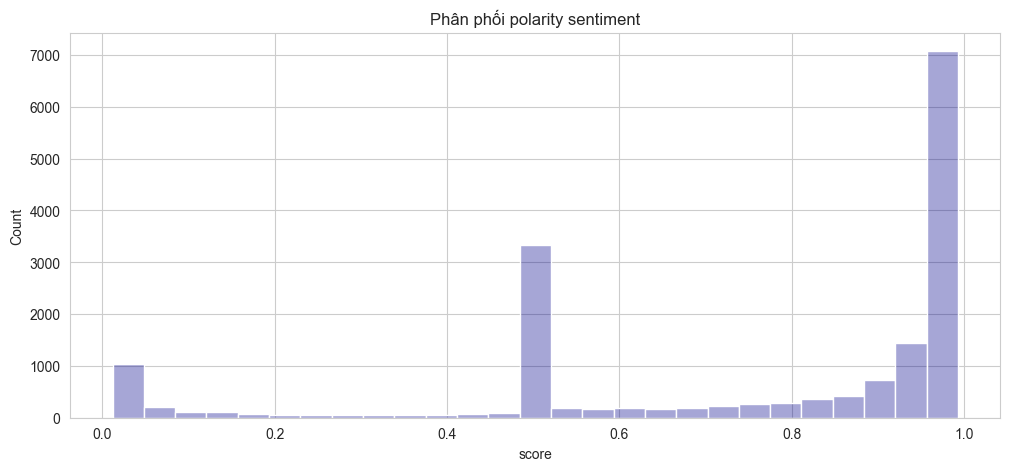

label         Negative  Neutral  Positive      Ratio
company year                                        
PAN     2019        55      160       403   7.327273
        2020        66      172       514   7.787879
        2021        88      139       607   6.897727
        2022        89      149       574   6.449438
        2023        55       59       297   5.400000
        2024        60      115       613  10.216667
        2025        69      127       534   7.739130
PLX     2018        55       96       262   4.763636
        2019       118      216       413   3.500000
        2020       121      274       447   3.694215
        2021        10        8        30   3.000000
        2022       182      246       587   3.225275
        2023        55       78       246   4.472727
        2024         3        9        28   9.333333
        2025        77      126       402   5.220779
PNJ     2019        54      128       405   7.500000
        2020        43       97       401   9.325581
        2021        34       46       265   7.794118
        2022       137       19       182   1.328467
        2023        72       57       381   5.291667
        2024        94       60       413   4.393617
        2025       106      107       499   4.707547
VNM     2019        61      102       406   6.655738
        2020        38       60       455  11.973684
        2021        64       63       458   7.156250
        2022        38       57       323   8.500000
        2023        57      107       479   8.403509
        2024        51       86       554  10.862745
        2025        78      163       713   9.141026

company,PAN,PLX,PNJ,VNM
year,,,,
2018,NaN,4.76,NaN,NaN
2019,7.33,3.50,7.50,6.66
2020,7.79,3.69,9.33,11.97
2021,6.90,3.00,7.79,7.16
2022,6.45,3.23,1.33,8.50
2023,5.40,4.47,5.29,8.40
2024,10.22,9.33,4.39,10.86
2025,7.74,5.22,4.71,9.14


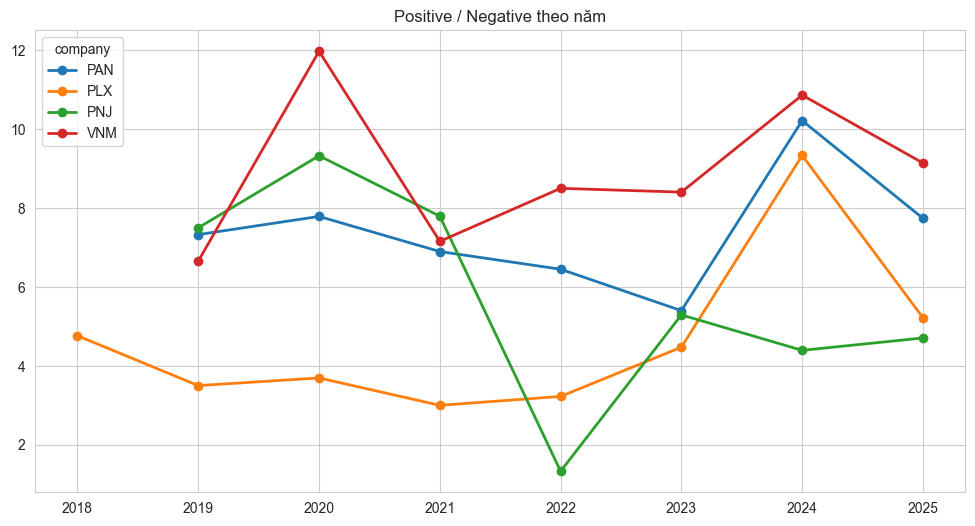

In [10]:
both_path = RESULT_DIR / "result_both.pkl"
if not both_path.exists():
    print("Chưa có sentiment. Chạy: python run_pipeline.py --lang vi")
else:
    df_both = pd.read_pickle(both_path)
    print(df_both["label"].value_counts(dropna=False))
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.histplot(df_both["score"].dropna(), color="darkblue", alpha=0.35, ax=ax)
    ax.set_title("Phân phối polarity sentiment")
    fig.savefig(FIGURE_DIR / "sentiment_hist.png", dpi=150, bbox_inches="tight")
    plt.show()

    counts = sentiment_ratio(df_both.dropna(subset=["label"]))
    display(counts)
    ratio = counts["Ratio"].unstack(level=0)
    display(ratio.round(2))
    fig, ax = plt.subplots(figsize=(12, 6))
    ratio.sort_index().plot(ax=ax, marker="o", linewidth=2)
    ax.set_title("Positive / Negative theo năm")
    ax.set_xlabel("")
    ax.grid(True)
    fig.savefig(FIGURE_DIR / "sentiment_ratio.png", dpi=150, bbox_inches="tight")
    plt.show()

## 9. Heatmap công ty–năm × 6 nhóm

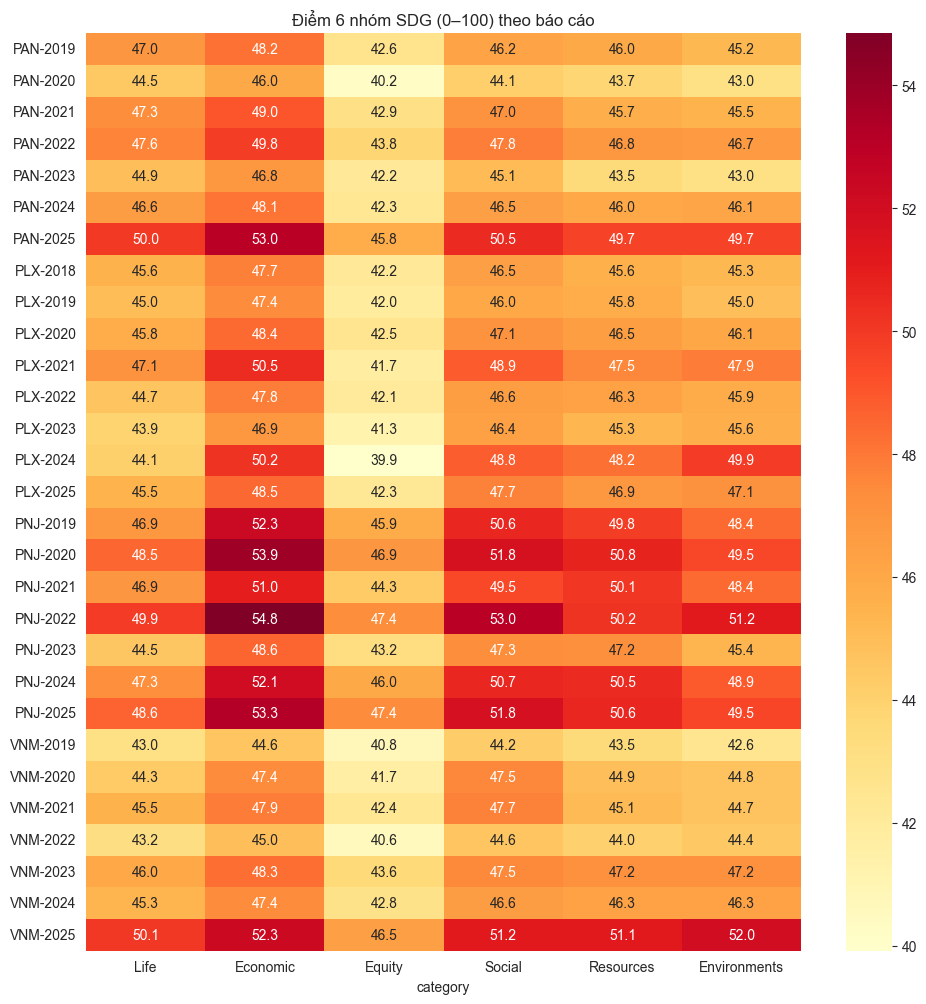

In [11]:
heat = df_cat.copy()
heat.index = [f"{c}-{y}" for c, y in heat.index]
fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(heat))))
sns.heatmap(heat[CATEGORY_ORDER], annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("Điểm 6 nhóm SDG (0–100) theo báo cáo")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "heatmap_6cat.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Phân tích Sentiment riêng biệt từng công ty

Cơ cấu tỷ lệ các câu **Positive / Neutral / Negative** và đường tỷ lệ **Pos/Neg Ratio** của từng doanh nghiệp qua các năm.

In [ ]:
from src.plots import plot_sentiment_by_company

both_path = RESULT_DIR / 'result_both.pkl'
if both_path.exists():
    df_both = pd.read_pickle(both_path)
    counts = sentiment_ratio(df_both.dropna(subset=['label']))
    fig_senti_path = plot_sentiment_by_company(counts)
    print(f'Đã lưu biểu đồ: {fig_senti_path}')
    
    # Hiển thị ảnh trong notebook
    from IPython.display import Image
    display(Image(filename=str(fig_senti_path)))
else:
    print('Chưa có kết quả sentiment. Chạy pipeline sentiment để xem biểu đồ này.')


## 11. Đối chiếu Biến động Giá Cổ phiếu & Phát hiện Dấu hiệu Tẩy xanh (Greenwashing)

Đối chiếu **Giá cổ phiếu đóng cửa cuối năm (VND)** với **Tỷ lệ Sentiment (Pos/Neg Ratio)** và **Điểm SDG Môi trường (Environments)**.

- **Hiện tượng phân kỳ (Scissors Effect / Divergence)**: Giá cổ phiếu sụt giảm hoặc đi ngang, nhưng giọng văn báo cáo và cam kết môi trường lại tăng vọt bất thường -> Cờ cảnh báo hành vi *Defensive Greenwashing* (Tô hồng báo cáo để xoa dịu thị trường).
- **Đồng pha thực chất (Substantive Performance)**: Hiệu quả tài chính và cam kết ESG cùng tăng trưởng hài hòa.

In [ ]:
from src.stock import fetch_annual_stock_prices, merge_stock_and_esg
from src.plots import plot_stock_vs_sentiment_greenwashing
from IPython.display import Image, display

# 1. Lấy dữ liệu giá cổ phiếu hàng năm
stock_df = fetch_annual_stock_prices(use_live=True)

both_path = RESULT_DIR / 'result_both.pkl'
if both_path.exists():
    df_both = pd.read_pickle(both_path)
    counts = sentiment_ratio(df_both.dropna(subset=['label']))
    
    # 2. Gộp chuỗi giá cổ phiếu, Sentiment và Điểm 6 nhóm SDG
    df_merged = merge_stock_and_esg(counts, df_cat, stock_df)
    
    # Hiển thị bảng đối chiếu các chỉ số chính
    cols_show = ['company', 'year', 'close_yearend', 'price_change_pct', 'Ratio', 'Environments', 'greenwashing_flag']
    cols_present = [c for c in cols_show if c in df_merged.columns]
    print('Bảng đối chiếu Cổ phiếu - Sentiment - Điểm SDG Môi trường:')
    display(df_merged[cols_present].round(2))
    
    # 3. Vẽ và hiển thị biểu đồ 2 trục phân kỳ Greenwashing
    fig_gw_path = plot_stock_vs_sentiment_greenwashing(df_merged)
    print(f'Đã lưu biểu đồ đối chiếu: {fig_gw_path}')
    display(Image(filename=str(fig_gw_path)))
else:
    print('Bảng giá cổ phiếu hàng năm:')
    display(stock_df)
    print('Chưa có kết quả sentiment để đối chiếu. Hãy chạy run_pipeline.py --sentiment-only.')


---
Khi PDF mới về: `python process_data.py` rồi `python run_pipeline.py --lang vi` (hoặc `en`), sau đó **Run All** notebook này — vẫn không cần load model.